--- Step 2: Loading Dataset ---
Dataset Shape: (150, 5)

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

--- Step 3: Splitting Data (80% Train / 20% Test) ---
Training set size: 120 samples
Testing set size: 30 samples

--- Step 4: Training the Classification Model ---
Model training complete!

--- Step 5: Model Evaluation ---
Model Accuracy: 100.00%

Confusion Matrix Layout:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Detailed Performance Report:
              precision  

/tmp/ipykernel_5102/3576987631.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis', ax=axes[1])


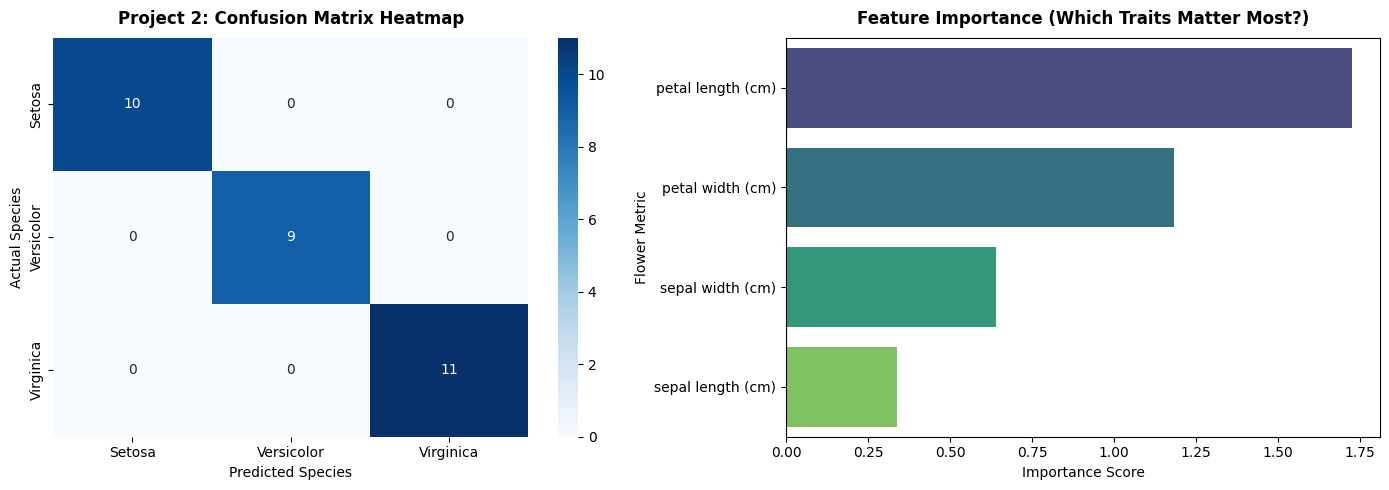

In [ ]:
# =========================================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# =========================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# =========================================================================
# STEP 2: LOAD AND UNDERSTAND THE DATASET (Slide: Architectural Paradigms)
# =========================================================================
print("--- Step 2: Loading Dataset ---")
iris = load_iris()

# Convert to a DataFrame for clean formatting
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows of the dataset:")
print(df.head())

# =========================================================================
# STEP 3: SPLIT DATA INTO TRAIN/TEST SETS (Slide: The Full Architecture)
# =========================================================================
print("\n--- Step 3: Splitting Data (80% Train / 20% Test) ---")
X = df[iris.feature_names]  # Features: Sepal/Petal lengths & widths
y = df['target']            # Target: Flower species labels

# test_size=0.2 enforces the exact 80/20 processing split from your guidelines
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# =========================================================================
# STEP 4: APPLY THE CLASSIFICATION ALGORITHM (Slide: The Logic Skeleton)
# =========================================================================
print("\n--- Step 4: Training the Classification Model ---")
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
print("Model training complete!")

# =========================================================================
# STEP 5: EVALUATION AND METRICS (Slide: Output Box Metrics)
# =========================================================================
print("\n--- Step 5: Model Evaluation ---")
y_pred = model.predict(X_test)

# Calculate Overall Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix Layout:")
print(cm)

# Detailed classification report (Precision, Recall, F1-score)
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# =========================================================================
# STEP 6: VISUALIZATIONS FOR YOUR REPORT
# =========================================================================
print("\n--- Generating Plots for Presentation/Report ---")

# Setup plot layout side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix Heatmap
species_names = ['Setosa', 'Versicolor', 'Virginica']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=species_names, yticklabels=species_names, ax=axes[0])
axes[0].set_title('Project 2: Confusion Matrix Heatmap', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Species', fontsize=10)
axes[0].set_ylabel('Actual Species', fontsize=10)

# Plot 2: Feature Importance Bar Chart
importance = np.mean(np.abs(model.coef_), axis=0)
feature_importance = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis', ax=axes[1])
axes[1].set_title('Feature Importance (Which Traits Matter Most?)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Importance Score', fontsize=10)
axes[1].set_ylabel('Flower Metric', fontsize=10)

plt.tight_layout()
plt.show()

# New Section